1. Importamos todas las librerias que vayamos a utilizar

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import (
    LinearRegression, LogisticRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

2. Cargamos los datos

In [ ]:
df = pd.read_csv("ai4i2020.csv")
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [23]:
from definiciones import describe_df, tipifica_variables
describe_df(df)


,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
Product ID,str,0.0,10000,100.00
Type,str,0.0,3,0.03
Air temperature [K],float64,0.0,93,0.93
Process temperature [K],float64,0.0,82,0.82
Rotational speed [rpm],int64,0.0,941,9.41
Torque [Nm],float64,0.0,577,5.77
Tool wear [min],int64,0.0,246,2.46
Machine failure,int64,0.0,2,0.02
TWF,int64,0.0,2,0.02
HDF,int64,0.0,2,0.02


In [22]:
tipifica_variables(df, 10, 0.3)

,nombre_variable,tipo_sugerido
0,Product ID,Numérica Continua
1,Type,Categórica
2,Air temperature [K],Numérica Continua
3,Process temperature [K],Numérica Continua
4,Rotational speed [rpm],Numérica Continua
5,Torque [Nm],Numérica Continua
6,Tool wear [min],Numérica Continua
7,Machine failure,Binaria
8,TWF,Binaria
9,HDF,Binaria


In [24]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# PROBLEMA DE NEGOCIO.
1. Precedir si una máquina va a fallar o no. (clasificación binaria) - TARGET = 'Machine failure'
2. Predecir que tipo de fallo ocurrirá. (clasificación multiclase) - TARGET = 'Type'

**DESCRIPCIÓN DE LAS VARIABLES**
- **UDI**: Identificador único de cada registro, no aporta información útil para el modelo.
- **Product ID**: Código del producto fabricado, mezcla tipo + número, puede contener información del producto.
- **Type**: Categoría del producto (L, M, H) que influye en el comportamiento de la máquina.
- **Air temperature**: Temperatura del aire alrededor de la máquina en Kelvin.
- **Process temperature**: Temperatura interna del proceso en Kelvin, normalmente más alta que la del aire.
- **Rotational speed**: Velocidad de rotación del motor en revoluciones por minuto.
- **Torque**: Par de torsión aplicado por la máquina, indica esfuerzo mecánico.
- **Tool wear**: Minutos acumulados de desgaste de la herramienta.
- **Machine failure**: Indica si ocurrió un fallo en la máquina (0 = no, 1 = sí).
- **TWF**: Fallo debido al desgaste de la herramienta.
- **HDF**: Fallo por problemas de disipación de calor.
- **PWF**: Fallo por pérdida o fallo de energía.
- **OSF**: Fallo por sobrecarga mecánica.
- **RNF**: Fallo aleatorio sin causa específica.


In [ ]:
TARGET = 'Machine failure' 

n_unique = df[TARGET].nunique()
print(f"Valores únicos en la target: {n_unique}")

if n_unique <= 20:
    print("→ Posible CLASIFICACIÓN")
    print(df[TARGET].value_counts())
else:
    print("→ Posible REGRESIÓN")
    print(df[TARGET].describe())

Valores únicos en la target: 2
→ Posible CLASIFICACIÓN
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [ ]:
# Eliminamos la columna UDI ya que son números desde el 1 al 10000 correlativos

# Producto ID, no lo eliminamos por qué nos podría dar información sobre el tipo de maquinaria que suele fallar

df.drop(columns="UDI", inplace=True)

PROBLEMA DE CLASIFICACIÓN DESBALANCEADO

3. Dividimos el data set en train y test, stratify = 'TARGET'  
>80 % para el train  
20 % para el test  

In [19]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 8000 filas  (80 %)
Test:  2000 filas  (20 %)


4. LIMPIEZA DE DATOS

In [20]:
# Tipos de datos
print(X_train.dtypes)
print()

# Valores faltantes
missing = X_train.isna().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
resumen = pd.DataFrame({'count': missing, '%': missing_pct})
print(resumen[resumen['count'] > 0].sort_values('%', ascending=False))
print()

# Duplicados
print(f"Duplicados: {X_train.duplicated().sum()}")

Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Empty DataFrame
Columns: [count, %]
Index: []

Duplicados: 0


5. MINIEDA

5.1 Estudiamos la TARGET

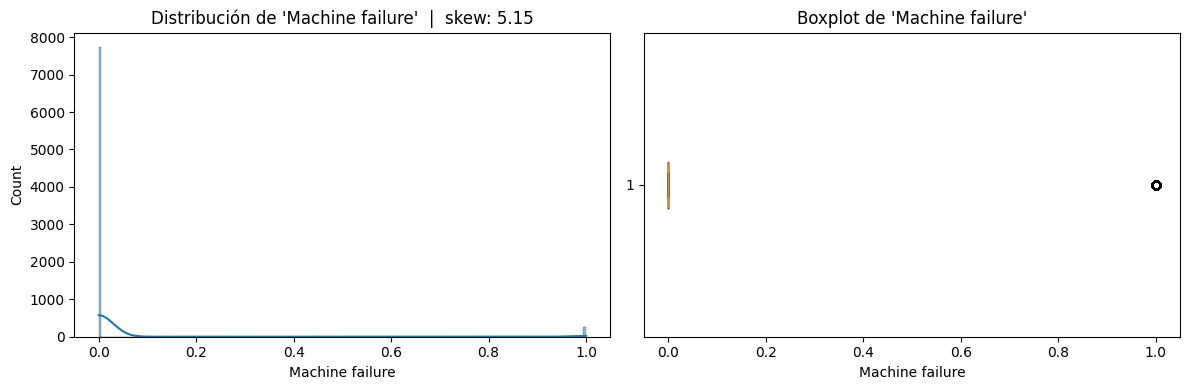

Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


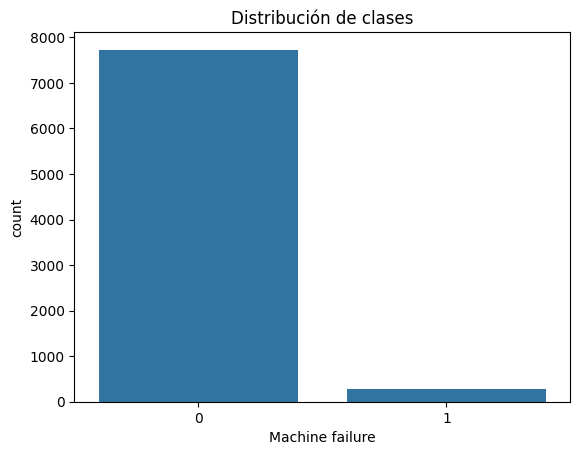

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con curva de densidad
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de '{TARGET}'  |  skew: {y_train.skew():.2f}")

# Boxplot para ver outliers
axes[1].boxplot(y_train.dropna(), vert=False)
axes[1].set_title(f"Boxplot de '{TARGET}'")
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

# Para clasificación — descomenta esto:
sns.countplot(x=y_train)
plt.title('Distribución de clases')
print(y_train.value_counts(normalize=True).mul(100).round(1))

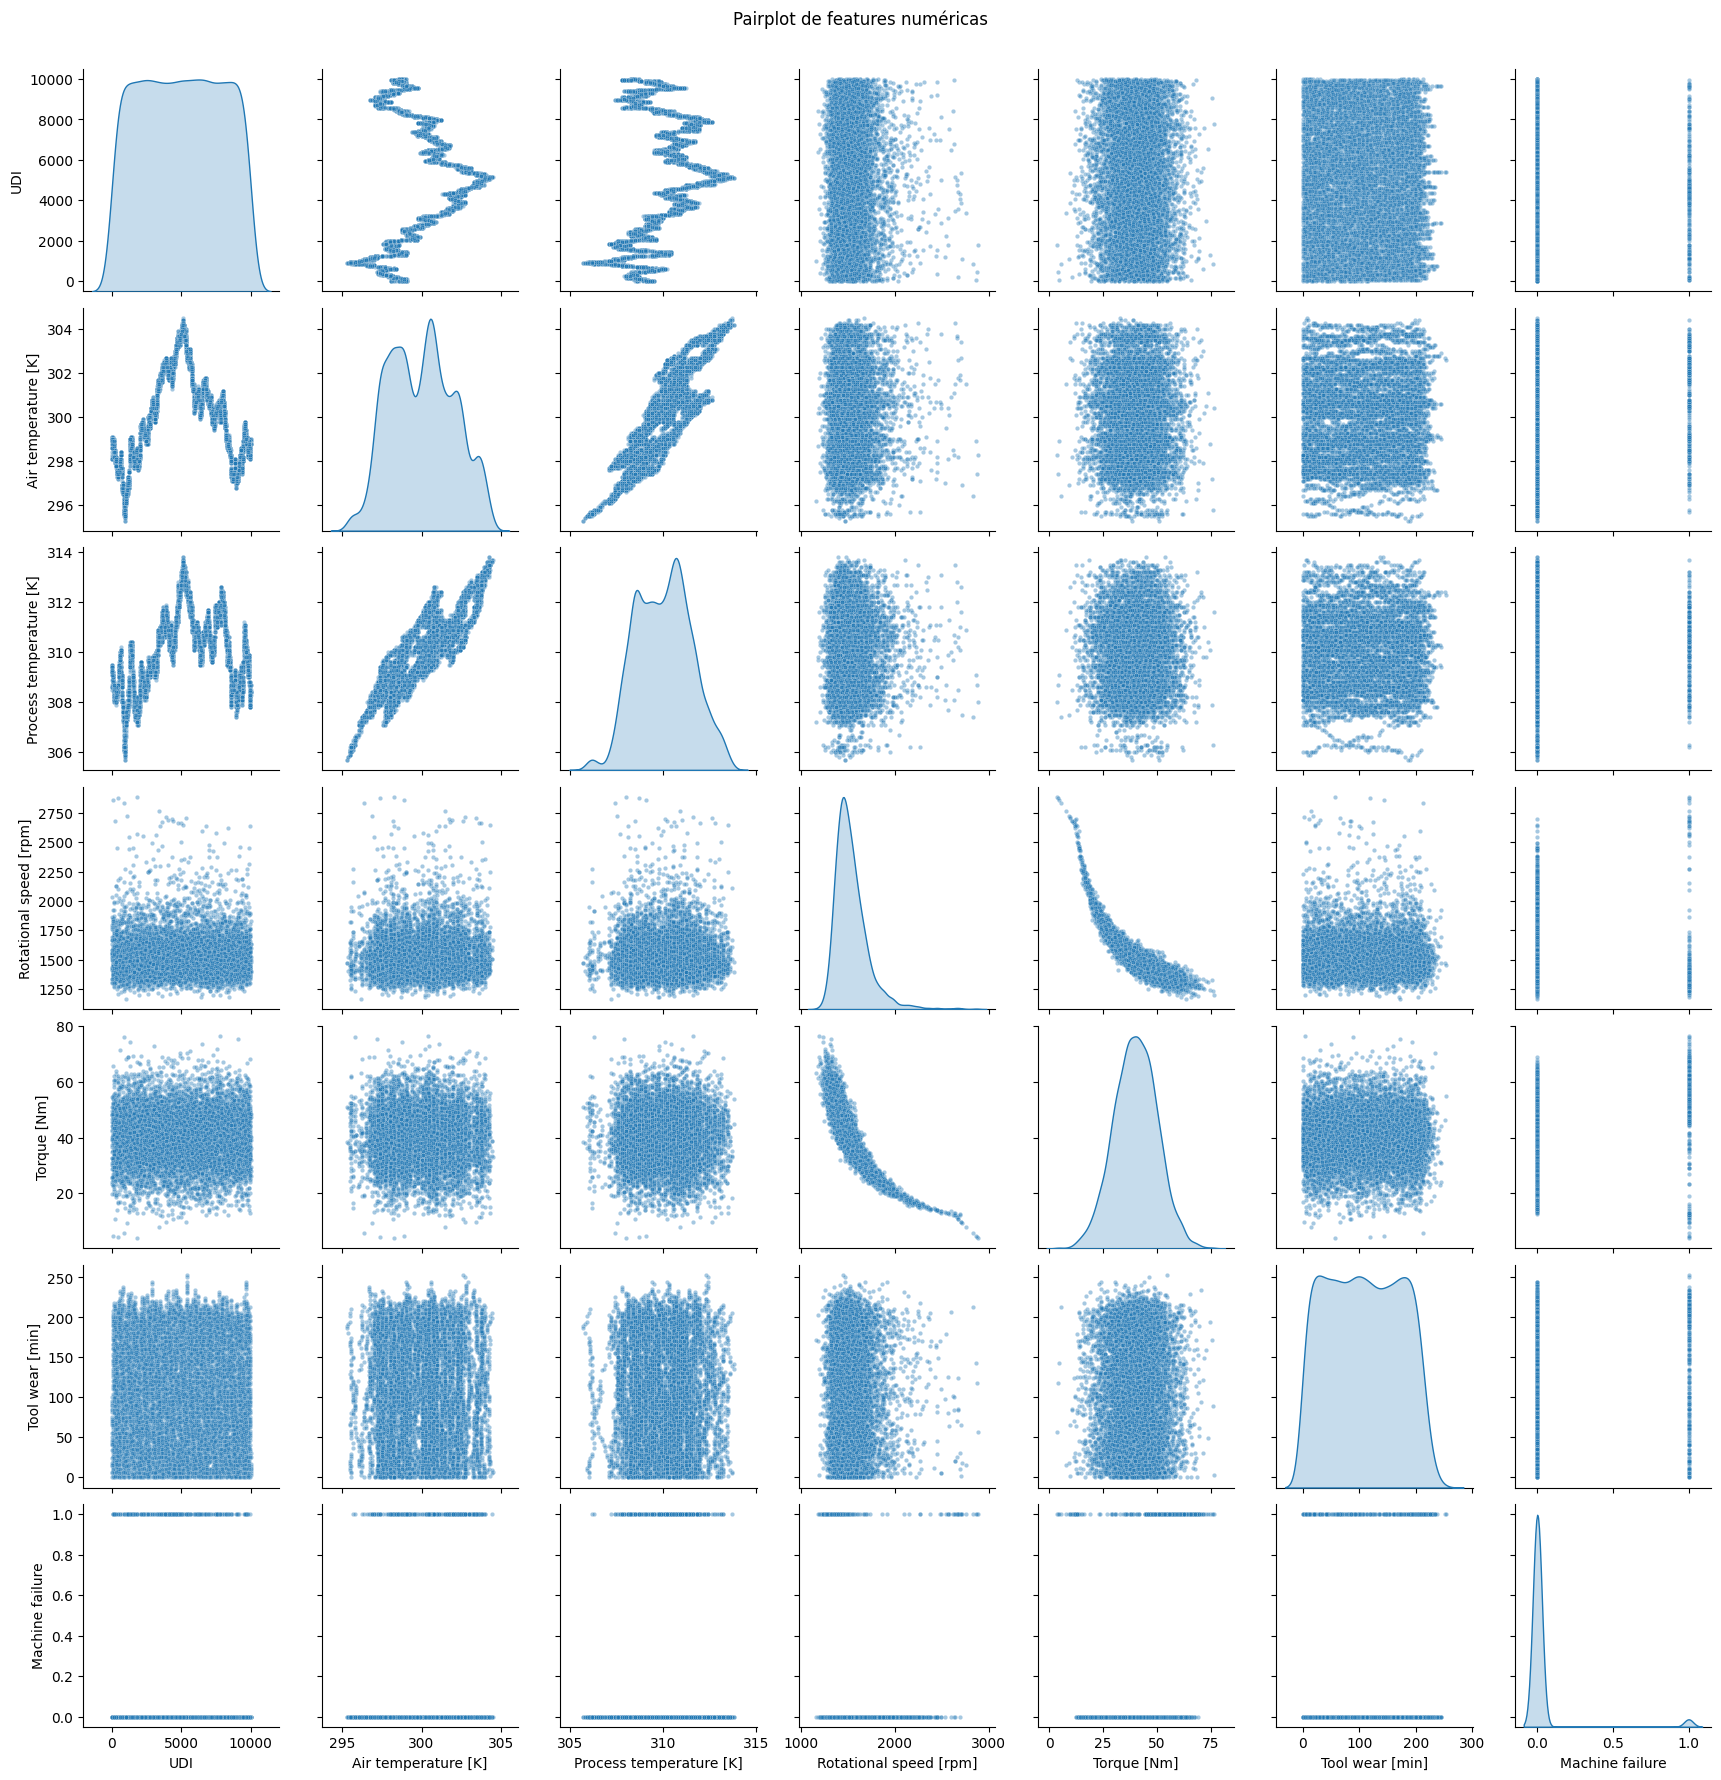

In [18]:
# Seleccionamos las features numéricas y añadimos la target
cols_plot = X_train.select_dtypes('number').columns.tolist()[:6]  # max 6 para legibilidad

sns.pairplot(
    X_train[cols_plot].join(y_train),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)
plt.suptitle('Pairplot de features numéricas', y=1.02)
plt.show()

5.2 FEATURES NUMERICAS

In [31]:
features_num = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

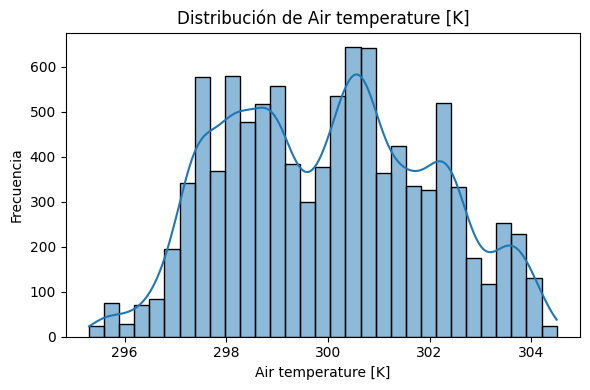

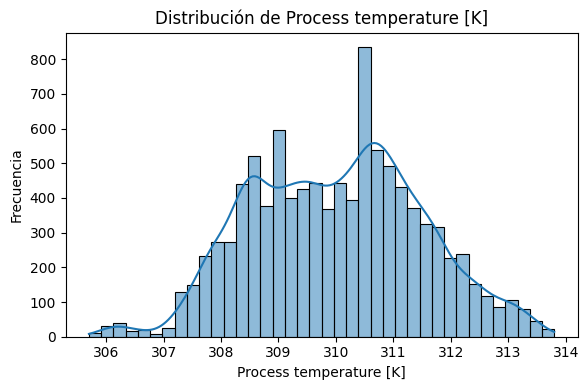

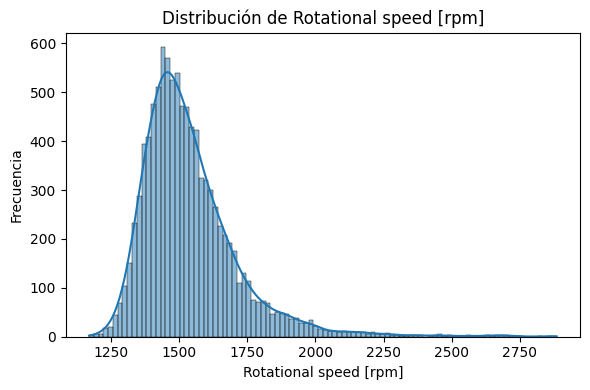

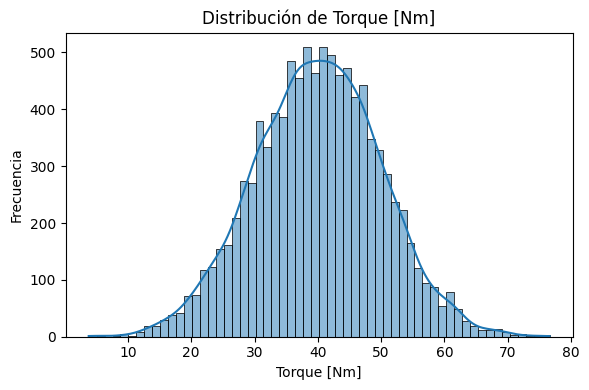

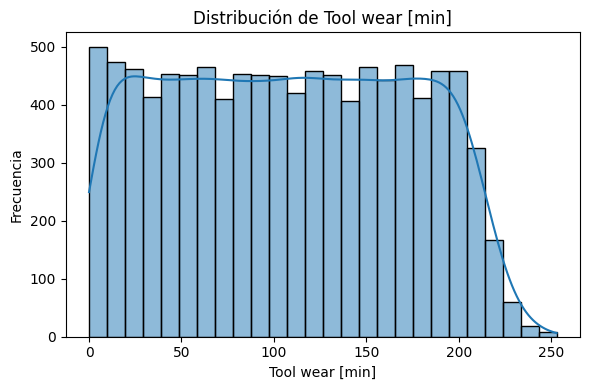

In [32]:
# Bucle para graficar cada variable numérica
for col in features_num:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


In [36]:
# Calculamos la correlación de las features num con la target (cat) con el método Anova

from sklearn.feature_selection import f_classif

# Separar X e y
X = df[features_num]
y = df["Machine failure"]   # <-- cambia aquí tu target categórico

# Calcular ANOVA
F_scores, p_values = f_classif(X, y)

# Crear tabla de resultados
anova_results = pd.DataFrame({
    "feature": features_num,
    "F_score": F_scores,
    "p_value": p_values
}).sort_values("p_value")

anova_results


,feature,F_score,p_value
3,Torque [Nm],379.867723,4.573805e-83
4,Tool wear [min],112.421077,3.976076e-26
0,Air temperature [K],68.608385,1.354800e-16
2,Rotational speed [rpm],19.559690,9.853543e-06
1,Process temperature [K],12.935260,3.240057e-04


In [37]:
# Seleccionar features relevantes según ANOVA (p < 0.05)
features_num_sel = anova_results[anova_results["p_value"] < 0.05]["feature"].tolist()
features_num_sel

['Torque [Nm]',
 'Tool wear [min]',
 'Air temperature [K]',
 'Rotational speed [rpm]',
 'Process temperature [K]']

“Según ANOVA, todas las variables numéricas presentan diferencias significativas entre las clases del target Machine failure (p < 0.05). Por tanto, rechazamos la hipótesis nula en todos los casos y concluimos que cada una de estas variables está estadísticamente asociada al fallo de máquina.”

In [38]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 4058 to 1424
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               8000 non-null   str    
 1   Type                     8000 non-null   str    
 2   Air temperature [K]      8000 non-null   float64
 3   Process temperature [K]  8000 non-null   float64
 4   Rotational speed [rpm]   8000 non-null   int64  
 5   Torque [Nm]              8000 non-null   float64
 6   Tool wear [min]          8000 non-null   int64  
 7   TWF                      8000 non-null   int64  
 8   HDF                      8000 non-null   int64  
 9   PWF                      8000 non-null   int64  
 10  OSF                      8000 non-null   int64  
 11  RNF                      8000 non-null   int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 869.1 KB


FEATURES CATEGÓRICAS

In [41]:
features_cat = ["Product ID", "Type", "TWF", "HDF", "PWF", "OSF", "RNF"]
features_cat

features_bin = ["TWF", "HDF", "PWF", "OSF", "RNF"]
features_cat

['Product ID', 'Type', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [ ]:
for col in features_cat:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Machine failure")
    plt.title(f"{col} vs Machine failure")
    plt.tight_layout()
    plt.show()


KeyboardInterrupt: 